# Mit historischen Wetterdaten das Wetter vorhersagen

<font color='red'>**Worum geht es?**</font>

In diesem Jupyter Notebook beschäftigen wir uns mit der Analyse von Wetterdaten und der Erstellung von Wettervorhersagen. Zentral geht es dabei um die Frage, wie ein KI-System basierend auf Wetterdaten zukünftige Wetterereignisse vorhersagen kann. Konkret soll das System entscheiden: **Wird es morgen regnen oder nicht?** Wir machen etwas etwas vereinfacht als Klassifikation mit "Regen" oder "Kein Regen". 

<font color='red'>**Wie gehen wir vor?**</font>

Wir orientieren uns dabei an einem für maschinelles Lernen typisches Vorgehen, wie es in der folgenden Abbildung dargestellt ist:
<img src="Weitere Ressourcen/ML Workflow.png" alt="" width="800"/>

In [1]:
# für unser Projekt brauchen wir ein paar Softwarepakete, die wir hier laden
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

## Schritt 1: Daten beschaffen
<style>
.side-by-side { display:flex; align-items:flex-start; gap:12px; }
.side-by-side > div { width:50%; box-sizing:border-box; }
.side-by-side img { width:100%; height:auto; display:block; }
@media (max-width:700px) {
  .side-by-side { flex-direction:column; }
  .side-by-side > div { width:100%; }
}
</style>
<div class="side-by-side">
  <div>
    <p>Es gibt verschiedene Möglichkeiten, an Wetterdaten zu gelangen. Eine Möglichkeit sind öffentlich zugängliche Daten, wie etwa vom Deutschen Wetterdienst (DWD). Dort können wir verschiedene Wetterstationen Wetterdaten herunterladen, in denen unter anderem Daten über die Temperatur, den Niederschlag, die Luftfeuchtigkeit und den Luftdruck enthalten sind.

### a) Daten laden
Von der Seite des <a href="https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/">DWD</a> wurde ein Datensatz einer Wetterstation heruntergeladen, die möglichst nah an Brakel steht. Wir haben die Wetterstation in Bad Lippspringe ausgewählt. </p>
  </div>
  <div>
    <img src="Weitere Ressourcen/BildWetterstation.png" alt="Beispielbild" width="600"/>
    <figcaption>Bildquelle: <a href="https://dwdbib.dwd.de/retrosammlung/content/pageview/976441">DWD</a></figcaption>
  </div>
</div>



In [2]:
wetterdaten = pd.read_csv("Wetterdaten_DWD/DatenWetterstationBadLippspringe.txt", sep=";")
wetterdaten.columns = wetterdaten.columns.str.strip()
wetterdaten['MESS_DATUM'] = pd.to_datetime(wetterdaten['MESS_DATUM'], format='%Y%m%d')
wetterdaten

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,eor
0,3028,1951-01-01,-999,-999.0,-999.0,5,0.4,8,0.0,5,6.0,5.5,-999.0,0.7,86.0,2.0,-5.4,-999.0,eor
1,3028,1951-01-02,-999,-999.0,-999.0,5,2.1,1,0.0,2,7.7,5.9,-999.0,1.6,86.0,3.0,0.0,-999.0,eor
2,3028,1951-01-03,-999,-999.0,-999.0,5,0.0,0,2.1,0,5.3,5.9,-999.0,0.5,91.0,1.8,-0.1,-999.0,eor
3,3028,1951-01-04,-999,-999.0,-999.0,5,0.5,7,1.9,0,4.7,5.5,-999.0,2.1,77.0,3.0,0.7,-999.0,eor
4,3028,1951-01-05,-999,-999.0,-999.0,5,3.0,1,0.0,0,7.3,7.7,-999.0,4.5,93.0,5.5,2.3,-999.0,eor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26781,3028,2024-12-27,10,2.2,0.7,9,0.0,0,5.6,0,5.1,6.3,1014.5,1.1,94.0,9.4,-2.4,-4.8,eor
26782,3028,2024-12-28,10,2.7,0.8,9,0.0,0,6.4,0,1.1,5.8,1010.4,0.4,92.0,10.0,-3.7,-5.8,eor
26783,3028,2024-12-29,10,7.0,1.6,9,0.2,6,0.0,0,6.9,5.7,1009.7,-0.9,99.0,1.9,-4.5,-7.1,eor
26784,3028,2024-12-30,10,8.2,3.8,9,0.0,6,0.0,0,7.9,6.8,1009.7,2.1,95.0,3.1,1.2,0.9,eor


### b) Daten verstehen
Bevor wir mit den Daten arbeiten können, müssen wir sie verstehen. Dazu schauen wir uns zunächst an, wo die Daten herkommen. Danach schauen wir uns die Spalten des Datensatzes an und überlegen, welche Informationen sie enthalten.

<font color='blue'>**Aufgabe:**</font> Was wissen wir über die Herkunft der Daten? Schaue dir die Metadaten zur Wetterstation an, um mehr über die Daten zu erfahren. Klicke <a href="Wetterdaten_DWD/Metadaten zu den Wetterdaten.html">hier</a>, um die Seite zu öffnen. Gehe die Seite durch und beantworte die Fragen in der nächsten Zelle.

*Zu beantworten:*
- Wo befindet sich die Wetterstation?


- Seit wann werden die Daten erfasst?


- Welche Wetterdaten werden erhoben? (siehe insbesondere die Tabelle zur Datengewinnung)


- Was erfährst du über fehlende/fehlerhafte Daten?



<font color='blue'>**Aufgabe:**</font> Schaue dir nun die Spalten der geladenen Datentabelle an. Versuche die Abkürzungen der Spaltennamen zu verstehen. Du findest die Abkürzungen in den Metadaten wieder (siehe vorherige Aufgabe: Tabelle zur Datengewinnung). Beschreibe die Abkürzungen in der nächsten Zelle.

*Zu beschreiben:*
- FM: 
- RSK: 
- SDK: 
- NM: 
- PM: 
- TMK: 
- UPM: 

## Schritt 2: Daten aufbereiten

Aktuell hat unsere Datentabelle viele Spalten, von denen wir nicht alle brauchen. Außerdem haben wir fehlende und fehlerhafte Daten, mit denen wir umgehen müssen. In diesem Schritt bereiten wir die Daten so auf, dass sie für die nächsten Schritte geeignet sind.

### a) Relevante Spalten für eine bessere Handhabbarkeit auswählen

<font color='blue'>**Aufgabe:**</font> Als erstes selektieren wir die Spalten, die für uns relevant sind. Wir wollen die Spalten MESS_DATUM, FM, RSK, SDK, NM, PM, TMK und UPM behalten. Alle anderen Spalten können wir entfernen. Selektiere die relevanten Spalten und speichere die neue Tabelle mit dem neuen Namen ```wetterdaten_selektiert``` ab. Ein Teil des Codes ist in der nächsten Zelle vorgegeben. Ergänze diesen Code.

*Tipp:* Wie selektiert man Spalten? Aktuell wird von der Tabelle die Spalte "MESS_DATUM" selektiert. Ergänze dahinter die anderen Spalten, die wir behalten wollen. Das Format ist dabei: ```[["MESS_DATUM", "NächsterSpaltenname", ...]]```


In [3]:
# Ergänze diesen Code
#wetterdaten_selektiert = wetterdaten[["MESS_DATUM"]]
wetterdaten_selektiert = wetterdaten[["MESS_DATUM", "FM", "RSK", "SDK", "NM", "PM", "TMK", "UPM"]]
wetterdaten_selektiert

,MESS_DATUM,FM,RSK,SDK,NM,PM,TMK,UPM
0,1951-01-01,-999.0,0.4,0.0,6.0,-999.0,0.7,86.0
1,1951-01-02,-999.0,2.1,0.0,7.7,-999.0,1.6,86.0
2,1951-01-03,-999.0,0.0,2.1,5.3,-999.0,0.5,91.0
3,1951-01-04,-999.0,0.5,1.9,4.7,-999.0,2.1,77.0
4,1951-01-05,-999.0,3.0,0.0,7.3,-999.0,4.5,93.0
...,...,...,...,...,...,...,...,...
26781,2024-12-27,0.7,0.0,5.6,5.1,1014.5,1.1,94.0
26782,2024-12-28,0.8,0.0,6.4,1.1,1010.4,0.4,92.0
26783,2024-12-29,1.6,0.2,0.0,6.9,1009.7,-0.9,99.0
26784,2024-12-30,3.8,0.0,0.0,7.9,1009.7,2.1,95.0


### b) Fehlende und fehlerhafte Daten behandeln

Man kann sich mit dem Befehl *describe()* einen Überblick über die Tabelle verschaffen. Dort werden für die jeweiligen Spalten verschiedene Werte angezeigt, wie zum Beispiel die Anzahl von Einträgen, der Mittelwert und weitere statistische Werte. In der Zeile "min" wird das Minimum in der jeweiligen Spalte angezeigt. Teilweise steht dort "-999.0", wobei es sich um fehlerhafte oder fehlende Daten handelt. Eine Möglichkeit damit umzugehen ist, diese Zeilen mit solchen Werten zu entfernen. 

In [4]:
wetterdaten_selektiert.describe()

,MESS_DATUM,FM,RSK,SDK,NM,PM,TMK,UPM
count,26786,26786.000000,26786.000000,26786.000000,26786.000000,26786.000000,26786.000000,26786.000000
mean,1988-02-26 14:49:33.433883,-267.638352,2.431080,3.514142,4.208273,463.037227,9.493149,77.087468
min,1951-01-01 00:00:00,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-17.600000,-999.000000
25%,1969-05-02 06:00:00,-999.000000,0.000000,0.100000,4.300000,-999.000000,4.400000,71.000000
50%,1988-05-01 12:00:00,2.100000,0.200000,2.700000,6.300000,993.400000,9.700000,80.000000
75%,2006-08-31 18:00:00,3.400000,3.000000,7.100000,7.600000,1000.900000,14.800000,86.000000
max,2024-12-31 00:00:00,11.100000,79.800000,16.100000,8.000000,1026.800000,31.100000,100.000000
std,NaN,444.914748,9.921092,24.098487,37.384428,883.633866,6.971391,32.319248


<font color='blue'>**Aufgabe:**</font> Zum Entfernen der Zeilen mit fehlerhaften oder fehlenden Daten können alle Zeilen selektieren, die passende Werte enthalten. Fehlende oder fehlerhafte Werte bekommen die Wert -999.0. Zum Beispiel könnten wir nur die Zeilen nehmen, deren Werte über -100 sind. Dann werden die Zeilen mit fehlenden oder fehlerhaften Werten gelöscht. In der nächsten Zelle ist bereits ein Teil des Codes vorgegeben, in dem die Tabelle nach der Spalte "FM" bereinigt wird. 

a) Kopiere die Zeile und verändere sie so, dass die Tabelle auch nach den anderen Spalten bereinigt wird. 

b) Führe die vorherige Code-Zelle mit der Übersicht zu den Spalten nochmal aus und überprüfe, ob die Minimalwerte nun realistischer sind.

In [5]:
# Erweitere diesen Code
wetterdaten_selektiert = wetterdaten_selektiert[wetterdaten_selektiert["FM"] >= -100]
wetterdaten_selektiert = wetterdaten_selektiert[wetterdaten_selektiert["RSK"] >= -100]
wetterdaten_selektiert = wetterdaten_selektiert[wetterdaten_selektiert["SDK"] >= -100]
wetterdaten_selektiert = wetterdaten_selektiert[wetterdaten_selektiert["NM"] >= -100]
wetterdaten_selektiert = wetterdaten_selektiert[wetterdaten_selektiert["PM"] >= -100]
wetterdaten_selektiert = wetterdaten_selektiert[wetterdaten_selektiert["TMK"] >= -100]
wetterdaten_selektiert = wetterdaten_selektiert[wetterdaten_selektiert["UPM"] >= -100]


## Zwischenschritt: Mit den Daten vertraut machen

In den Daten stecken viele Informationen. Um uns mit den Daten vertraut zu machen, visualisieren wir einen Teil der Daten. Als Beispiel schauen wir uns die Entwicklung der Temperatur (Spalte "TMK") über die Zeit an und überprüfen, ob wir dort das sehen, was wir auch vermuten würden: *über die Jahre wird es wärmer*.

<font color='blue'>**Aufgabe:**</font> In der nächsten Zelle wird bereits ein Liniendiagramm erstellt. Beschreibe in der übernächsten Zelle, was du in dem Diagramm siehst. 

<Axes: xlabel='MESS_DATUM'>

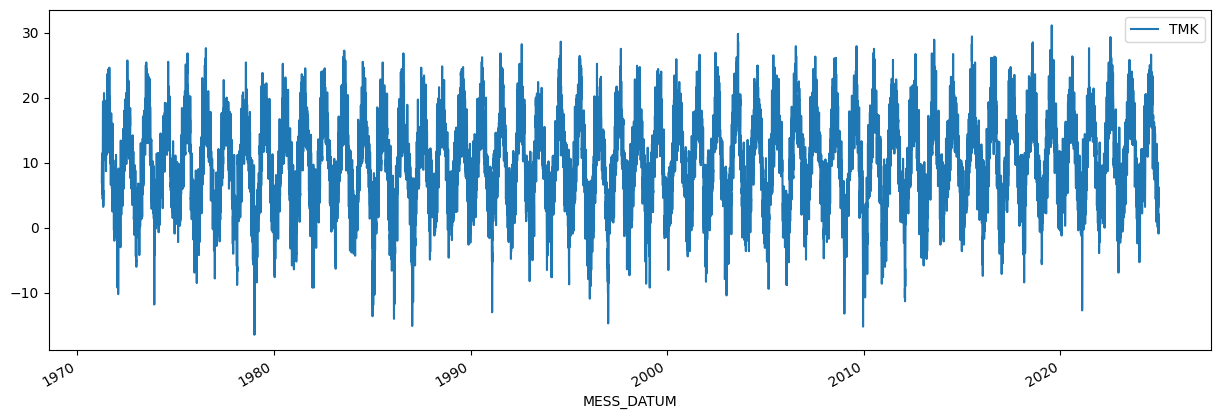

In [6]:
wetterdaten_selektiert.plot(x="MESS_DATUM", y="TMK", figsize=(15, 5))

-> Notiere hier deine Beobachtungen
...

Aktuell enthält das Diagramm zu viele Daten, wie etwa die verschiedenen Monate, die die Schwankungen erzeugen. In der nächsten Zelle wird das Diagramm so angepasst, dass nur ein Monat pro Jahr angezeigt wird und die Tageswerte in diesen Monaten zu jeweils einem Mittelwert zusammengefasst. 

<font color='blue'>**Aufgabe:**</font> Beschreibe in der übernächsten Zelle, was du in dem neuen Diagramm siehst. Teste deine Beobachtung anhand eines anderen Monats.

<Axes: xlabel='Jahr'>

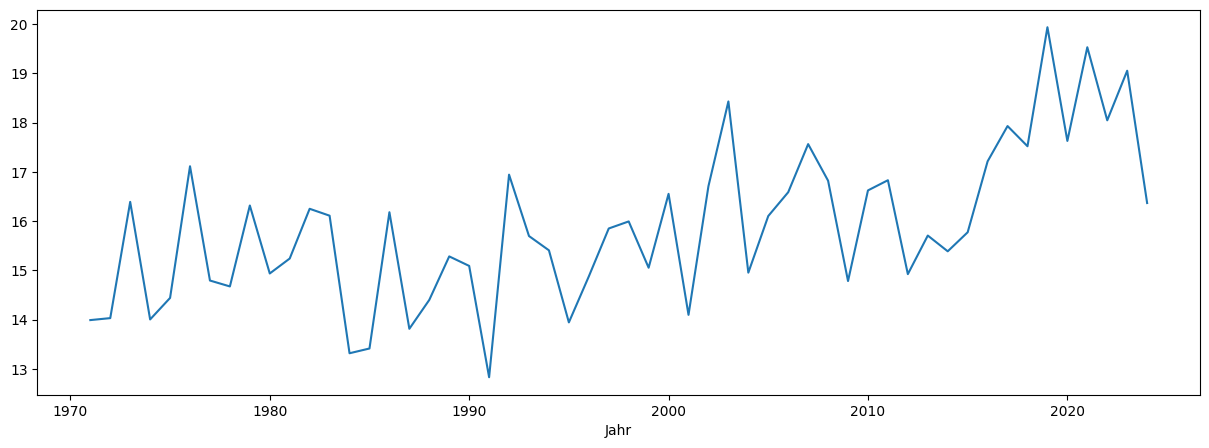

In [7]:
ausgewaehlterMonat = 6      # <- hier wird der Monat festgelegt

wetterdaten_vis = wetterdaten_selektiert[wetterdaten_selektiert['MESS_DATUM'].dt.month == ausgewaehlterMonat]
wetterdaten_vis['Jahr'] = wetterdaten_vis['MESS_DATUM'].dt.year
wetterdaten_vis_grouped = wetterdaten_vis.groupby('Jahr')['TMK'].mean()
wetterdaten_vis_grouped.plot(x='MESS_DATUM', y=['TMK'], figsize=(15, 5))

-> Notiere hier deine Beobachtungen
...

## Schritt 3: Merkmale identifizieren und erstellen

### a) Zielmerkmal definieren (Was soll vorhergesagt werden?)

Wir wollen vorhersagen, ob es morgen regnet oder nicht. Das heißt, dass unsere KI mit den Werten in einer Zeile (entspricht einem Tag) entscheiden soll, ob es morgen regnet. Damit die KI, dies "lernen" kann, brauchen wir allerdings die Erfahrungswerte, ob es jeweils geregnet hat oder nicht. 

*Beispiel:* Unser KI-System soll für den 1.4.1971 vorhersagen können, ob am nächsten Tag Regen ist. Heute wissen wir, ob es an dem 2.4. geregnet hat oder nicht. Dafür schauen wir uns die Daten in der nächsten Zeile an. Unser KI-System soll das mit den Tagesdaten vom 1.4. entscheiden können: 
<img src="Weitere Ressourcen/Beispielbild.png" width="450">

<font color='blue'>**Aufgabe:**</font> Erstelle in der Datentabelle eine neue Spalte mit dem Namen "morgen_regen". Die Spalte können wir mit den Werten aus der Spalte RSK belegen, allerdings brauchen wir immer die Werte aus der nächsten Zeile. Dafür benutzen wir die Methode *shift(-1)*. Vervollständige den Code in der nächsten Zelle.

*Tipp:* Mit ```tabellennamen["neuerSpaltenname"]``` wird in einer Tabelle mit dem Namen *tabellennamen* eine neue Spalte mit dem Namen *neuerSpaltenname* erstellt. Hinter dem *=* steht dann, was in der Spalte eingetragen werden soll. 

In [8]:
# Ergänze den Code vor dem Gleichzeichen
wetterdaten_selektiert['morgen_regen'] = wetterdaten_selektiert['RSK'].shift(-1)

wetterdaten_selektiert

,MESS_DATUM,FM,RSK,SDK,NM,PM,TMK,UPM,morgen_regen
7152,1971-04-01,1.8,0.0,3.0,6.0,985.9,7.0,74.0,0.0
7153,1971-04-02,3.2,0.0,9.3,3.0,979.2,9.1,76.0,0.0
7154,1971-04-03,1.7,0.0,0.1,5.0,979.9,8.4,86.0,5.5
7155,1971-04-04,2.7,5.5,8.2,1.3,980.0,10.2,72.0,0.0
7156,1971-04-05,1.7,0.0,8.7,4.7,983.4,9.9,81.0,0.0
...,...,...,...,...,...,...,...,...,...
26781,2024-12-27,0.7,0.0,5.6,5.1,1014.5,1.1,94.0,0.0
26782,2024-12-28,0.8,0.0,6.4,1.1,1010.4,0.4,92.0,0.2
26783,2024-12-29,1.6,0.2,0.0,6.9,1009.7,-0.9,99.0,0.0
26784,2024-12-30,3.8,0.0,0.0,7.9,1009.7,2.1,95.0,0.0


Aktuell steht in der Spalte "morgen_regen" noch die Regenmenge. Später soll unser KI-System aber nur sagen können, ob es regnet (Wert: 1) oder nicht (Wert: 0). In der nächsten Code-Zelle werden die Werte in der Spalte morgen_regen entsprechend überschrieben. Führe sie aus. 

In [9]:
wetterdaten_selektiert['morgen_regen'] = wetterdaten_selektiert['morgen_regen'].apply(lambda x: 1 if x > 0 else 0)
wetterdaten_selektiert

,MESS_DATUM,FM,RSK,SDK,NM,PM,TMK,UPM,morgen_regen
7152,1971-04-01,1.8,0.0,3.0,6.0,985.9,7.0,74.0,0
7153,1971-04-02,3.2,0.0,9.3,3.0,979.2,9.1,76.0,0
7154,1971-04-03,1.7,0.0,0.1,5.0,979.9,8.4,86.0,1
7155,1971-04-04,2.7,5.5,8.2,1.3,980.0,10.2,72.0,0
7156,1971-04-05,1.7,0.0,8.7,4.7,983.4,9.9,81.0,0
...,...,...,...,...,...,...,...,...,...
26781,2024-12-27,0.7,0.0,5.6,5.1,1014.5,1.1,94.0,0
26782,2024-12-28,0.8,0.0,6.4,1.1,1010.4,0.4,92.0,1
26783,2024-12-29,1.6,0.2,0.0,6.9,1009.7,-0.9,99.0,0
26784,2024-12-30,3.8,0.0,0.0,7.9,1009.7,2.1,95.0,0


Schauen wir uns das Merkmal "morgen_regen" noch genauer an. In der nächsten Zelle wird ein Diagramm mit Häufigkeiten zu den beiden Werten dargestellt. Die Anzahl gibt die Anzahl der Tage wieder. Der Unterschied ist in Ordnung für unser Modell. Generell sollten beiden Kategorien in den Trainingsdaten ähnlich oft vorkommen. 

<Axes: xlabel='morgen_regen'>

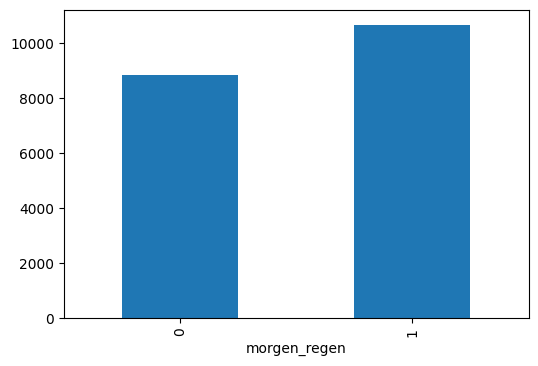

In [10]:
häufigkeit = wetterdaten_selektiert["morgen_regen"].value_counts().sort_index()
häufigkeit.plot(kind="bar", figsize=(6, 4))

### b) Auswahl der Merkmale für die Vorhersage

<font color="blue">**Aufgabe:**</font> Nun musst du entscheiden, mit welchen Daten dein Modell trainiert werden soll. Mit anderen Worten: basierend auf welchen Daten dein Modell entscheiden soll, ob es morgen regnet oder nicht. Recherchiere im Internet, welche Merkmale des Wetters einen Hinweis darauf geben könnten, ob es am nächsten Tag regnet oder nicht. Notiere deine Rechercheergebnisse in der nächsten Zelle. 

-> Notiere hier deine Rechercheergebnisse
...

<font color="blue">**Aufgabe:**</font> Wähle nun die Spalten aus, mit denen dein Modell trainiert werden soll. Ergänze sie als Liste zwischen den eckigen Klammern in der nächsten Zelle. Das Format sollte dann so aussehen: ```["spaltenname1", "spaltenname2", ...]```. Führe die Zelle danach aus. 

*Hinweis:* Bei deinen Merkmalen, darf "regen_morgen" natürlich nicht vorkommen.

In [11]:
# Wichtig: 'morgen_regen' darf nicht als Merkmal verwendet werden
merkmale = ['NM', 'PM', 'FM']

## Schritt 4: Modell trainieren

Bei maschinellem Lernen sprechen wir von einem Modell, das trainiert wird. Da wo wir sonst ein Programm hatten, wonach ein Ergebnis ermittelt wird, ist es bei einem KI-System das Modell, das auf eine Eingabe angewendet wird. Bei uns wird das Modell dafür da sein, mithilfe von den Wetterdaten an einem Tag vorherzusagen, ob es am nächsten Tag regnen wird oder nicht -- auch für ganz neue Daten, die wir vorher nicht kannten.

### a) Unterteilen der Daten für das Training und Testen
Bevor wir ein Modell trainieren, unterteilen wir unsere Daten in sogenannte Trainings- und Testdaten. Mit den Trainingsdaten erstellen wir unser Modell, mit den Testdaten können wir hinterher überprüfen, wie gut die Vorhersagen sind. Dafür teilen wir unsere Wetterdaten so auf: 

- 80% der Daten werden die Trainingsdaten
- 20% der Daten werden die Testdaten

In [12]:
X = wetterdaten_selektiert[merkmale]
y = wetterdaten_selektiert['morgen_regen']

# Unterteilen der Daten in Trainings- und Testdaten (X sind die Daten und y die Vorhersage)
#idx = int(len(wetterdaten_selektiert) * 0.8)
#X_train = X.iloc[:idx]
#y_train = y.iloc[:idx] 
#X_test = X.iloc[idx:]
#y_test = y.iloc[idx:]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2)

print(f"Die Wetterdaten von {len(X_train)} Tagen bilden die Trainingsdaten.")
print(f"Die Wetterdaten von {len(X_test)} Tagen bilden die Testdaten.")

Die Wetterdaten von 15601 Tagen bilden die Trainingsdaten.
Die Wetterdaten von 3901 Tagen bilden die Testdaten.


### b) Welche Methode des maschinellen Lernens nehmen wir?

Wir kennen beispielsweise schon die **Entscheidungsbäume**. Mit einem Entscheidungsbaum könnten wir den Regen am nächsten Tag vorhersagen. Damit probieren wir es nun aus. 

### c) Modell trainieren
In der Unterrichtsreihe hast du zuvor schon gesehen, wie ein Entscheidungsbaum erstellt wird. Dafür gibt es auch Softwarepakete, die dieses Erstellen des Entscheidungsbaums übernehmen. Ein solches Paket nutzen wir hier. Wir übergeben dem *DecisionTreeClassifier* unsere Daten und ein paar Einstellungswerte. Damit wird dann ein Entscheidungsbaum automatisch erstellt. Schritte dabei waren Einen guten Datensplit finden usw. 

In [13]:
entscheidungsbaum = DecisionTreeClassifier(random_state=42, 
                                           max_depth=len(merkmale), # legt die maximale Tiefe des Baums fest
                                           min_samples_leaf=20      # verhindert winzige Blätter im Baum
                                           )
entscheidungsbaum.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

<font color="blue">**Aufgabe:**</font> 

In [14]:
# Beispielvorhersage
mess_datum = "2024-06-24"   # wähle hier ein anderes Beispieldatum aus, um die Vorhersage zu testen

testtagesdaten = wetterdaten_selektiert[wetterdaten_selektiert['MESS_DATUM'] == mess_datum]
display(testtagesdaten)
vorhersage = entscheidungsbaum.predict(testtagesdaten[merkmale])
print("Vorhersage:", "Regen" if vorhersage[0] == 1 else "kein Regen")
print("Wirklichkeit:", "Regen" if testtagesdaten['morgen_regen'].values[0] == 1 else "kein Regen")

,MESS_DATUM,FM,RSK,SDK,NM,PM,TMK,UPM,morgen_regen
26595,2024-06-24,1.4,0.0,12.4,1.5,1001.2,19.5,69.0,0


Vorhersage: kein Regen
Wirklichkeit: kein Regen


### d) Wie sieht der Entscheidungsbaum jetzt aus? 
<font color="blue">**Aufgabe:**</font> In der nächsten Zelle wir der Entscheidungsbaum visualisiert. Schaue dir den obersten Teil des Baums an und versuche zu verstehen, was die erste Zeile in einem der Kästchen bedeutet. Beschreibe deine Erklärung in der übernächsten Zelle.

*Beispiel:*
<img src="Weitere Ressourcen/Beispiel Ausschnitt Entscheidungsbaum.png" width = "150">

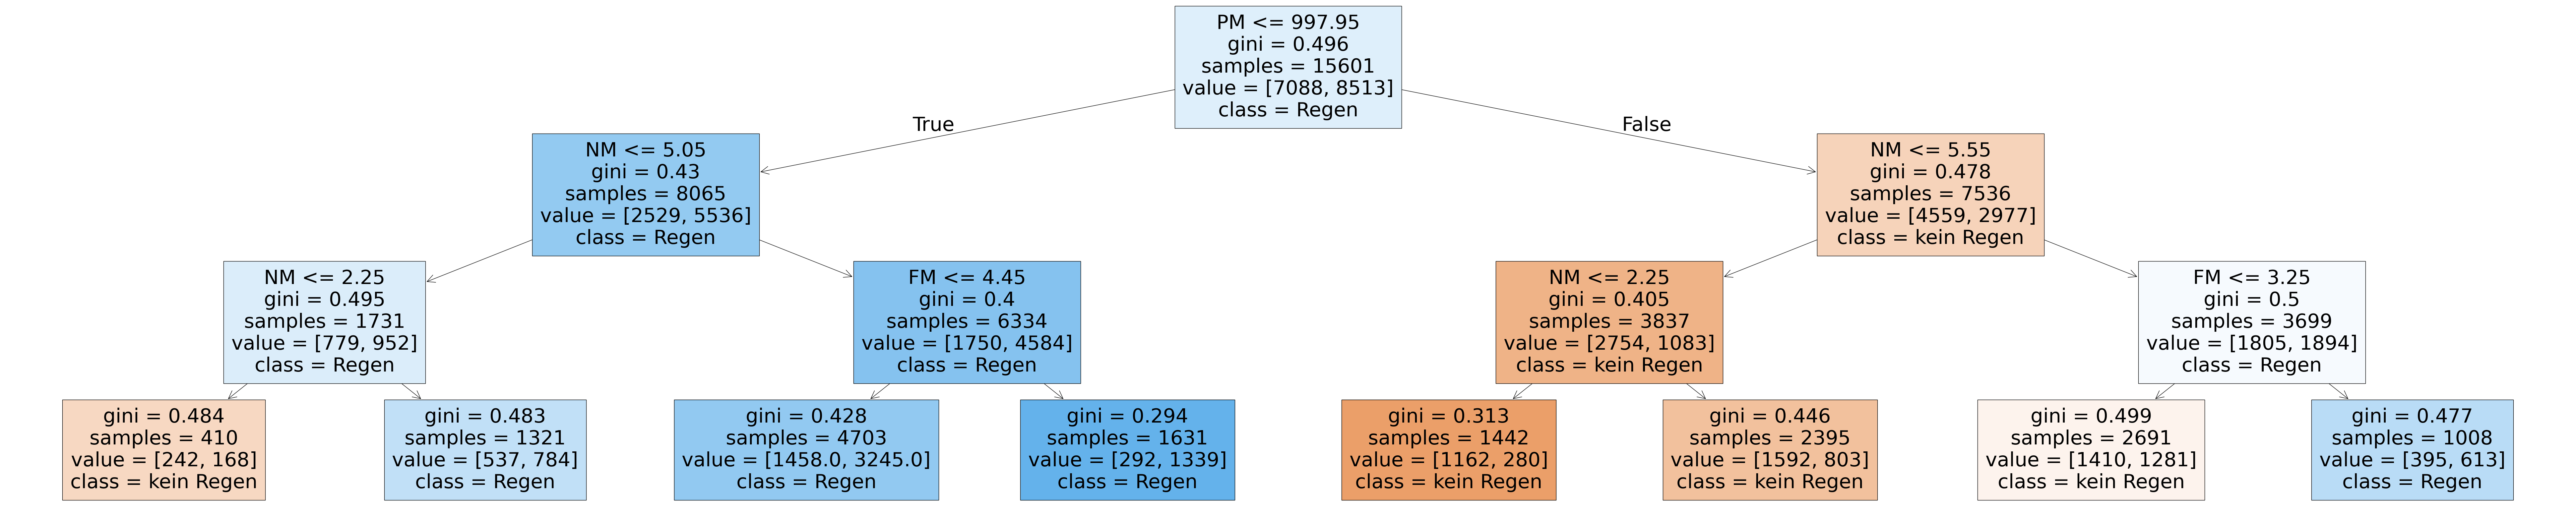

In [15]:
plt.figure(figsize=(100, 20))
plot_tree(entscheidungsbaum, feature_names=merkmale, class_names=["kein Regen", "Regen"], filled=True)
plt.show()

-> Notiere hier deine Beschreibung

## Schritt 5: Modell testen und bewerten

Mithilfe der Testdaten, die wir vor dem Training des Modells herausgenommen haben, können wir nun testen, wie gut der Entscheidungsbaum ist.

### a) Modell auf Testdaten anwenden
Der Anteil der richtigen Vorhersagen wird als Genauigkeit bezeichnet. Diese wird für die Trainings- und Testdaten in der nächsten Zelle berechnet. 

In [16]:
# Vorhersagen für die Testdaten erstellen
test_vorhersagen = entscheidungsbaum.predict(X_test)

# Genauigkeit des Modells ermitteln
train_score = accuracy_score(y_train, entscheidungsbaum.predict(X_train))
test_score = accuracy_score(y_test, test_vorhersagen)

print(f"Mit den Trainingsdaten hat das Modell eine Genauigkeit von: {train_score:.3f}")
print(f"Mit den Testdaten hat das Modell eine Genauigkeit von: {test_score:.3f}")

Mit den Trainingsdaten hat das Modell eine Genauigkeit von: 0.666
Mit den Testdaten hat das Modell eine Genauigkeit von: 0.665


Diese Werte sagen noch nicht so viel aus. Zum Beispiel wissen wir nicht, wobei das Modell richtig gelegen hat: sagt das Modell etwa oft richtig Regen voraus oder eher oft falsch? Um das genauer zu erkennen, betrachtet man vier unterschiedliche Situationen. Dazu wird in der nächsten Zelle eine sogenannte Vierfeldertafel erstellt (Tabelle mit vier Feldern). 

<font color="blue">**Aufgabe:**</font> Untersuche das erzeugte Bild und versuche nachzuvollziehen, was die vier bunten Felder in der Mitte bedeuten. Beschreibe deine Interpretation in der übernächsten Zelle. Benenne dabei neben einer Erklärung des gesamten Bildes jedes der vier Felder mit einem treffenden Namen.

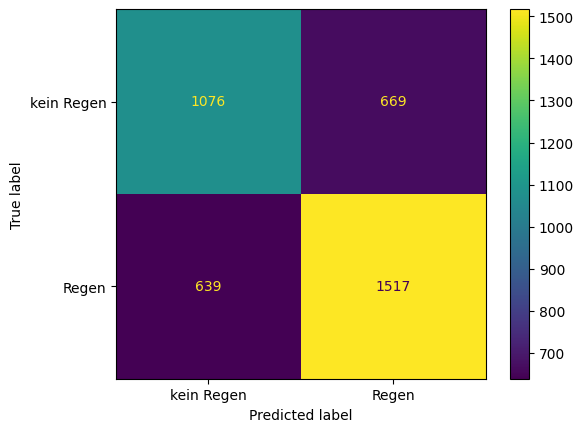

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, test_vorhersagen),
    display_labels=["kein Regen", "Regen"]
)
disp.plot(values_format="d")

-> Notiere hier deine Interpretation
...

### b) Welche Merkmale waren gut? 
Bei einem Entscheidungsbaum kann man gut herausfinden, welche der Merkmale, die wir für das Training benutzt haben, auch gut für das Modell waren. Beim Erstellen des Entscheidungsbaums werden verschiedene Merkmale getestet und die Merkmale für die Entscheidungsregeln verwendet, die gut funktionieren. Man nennt das die Wichtigkeit der Merkmale (auch Feature Importance genannt).

<font color="blue">**Aufgabe:**</font> Führe die nächste Zelle aus und schaue dir das Diagramm an. Entscheide mithilfe des Diagramms, welche deiner gewählten Merkmale für dein Modell hilfreich waren. Bewerte diese "Wichtigkeit der Merkmale" im Sachzusammenhang. Notiere deine Ergebnisse in der übernächsten Zelle.

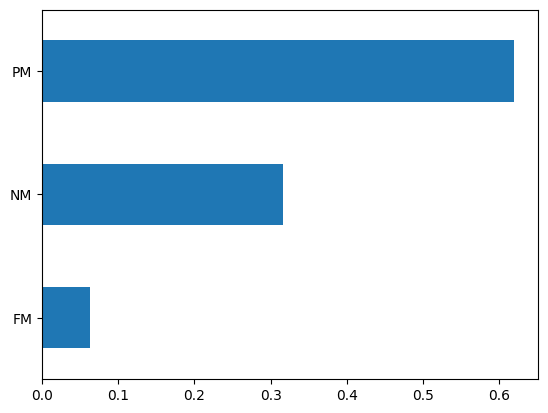

In [18]:
importance = pd.Series(entscheidungsbaum.feature_importances_, index=entscheidungsbaum.feature_names_in_)
importance.sort_values().plot(kind="barh")
plt.show()

-> Notiere hier deine Ergebnisse
...

## Schritt 6: Optimierung
Zur Weiterentwicklung des Modells kannst du nun deine neuen Erkenntnisse nutzen, um die Auswahl der Merkmale zu verändern. 

<font color="blue">**Aufgabe:**</font> Gehe zurück zum Schritt 3b und verändere die Auswahl der Merkmale. Führe danach alle Zellen aus (oben der Doppepfeil). Überprüfe, ob sich dein Modell verbessert hat. Notiere hier die Veränderungen, die du beobachtest. 

-> Notiere hier deine Beobachtungen
...

## Zusatzaufgabe
Wir haben einen Entscheidungsbaum erstellt, mit dem wir die Vorhersagen für den Regen am nächsten Tag gemacht haben. Ein weiteres Verfahren aus dem maschinellen Lernen entwickelt die Idee der Entscheidungsbäume weiter. Das so genannte **Random Forest** Verfahren nutzt viele kleine Entscheidungsbäume (z.B. 100 Stück), die mit wenigen Daten und wenigen Merkmalen erstellt werden, und lässt anschließend die vielen Bäume jeweils eine Vorhersage treffen. Per Mehrheitsprinzip wird anschließend eine gemeinsame Vorhersage abgeleitet. 

*Beispiel:*
- Entscheidungsbaum 1 sagt "Regen"
- Entscheidungsbaum 2 sagt "Regen"
- Entscheidungsbaum 3 sagt "Kein Regen"
- ... 
Dann entscheidet die Mehrheit. 

<font color="blue">**Aufgabe:**</font> Führe die beiden nächsten Zellen aus. Stelle in der darauffolgenden Zelle Vermutungen an, warum eine solches Random Forest Verfahren besser sein könnte als ein einzelner Entscheidungsbaum. 

In [19]:
waldmodell = RandomForestClassifier(
    n_estimators=200,      # Anzahl der Bäume
    max_depth=6,           # maximale Tiefe der einzelnen Bäume
    random_state=42       # für reproduzierbare Ergebnisse
)
waldmodell.fit(X_train, y_train)

print("Genauigkeit mit Trainingsdaten:", round(accuracy_score(y_train, waldmodell.predict(X_train)), 3))
print("Genauigkeit mit Testdaten:", round(accuracy_score(y_test, waldmodell.predict(X_test)), 3))

Genauigkeit mit Trainingsdaten: 0.684
Genauigkeit mit Testdaten: 0.666


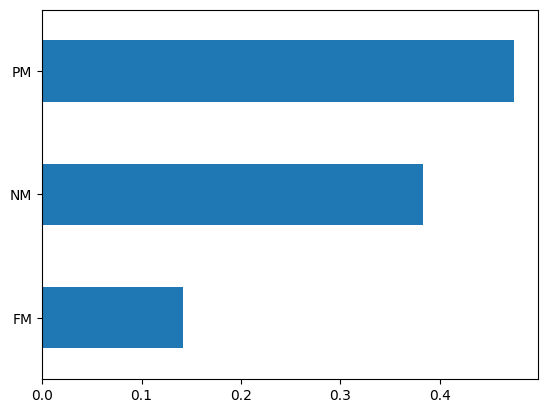

In [20]:
pd.Series(waldmodell.feature_importances_, index=X_test.columns).sort_values().plot(kind="barh")
plt.show()


-> Notiere hier deine Vermutungen 
...